<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week05%ED%8C%8C%EC%9D%B4%ED%86%A0%EC%B9%982.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.4 파이토치 코드 맛보기

In [1]:
import torch
import torch .nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
dataset=pd.read_csv('/car_evaluation.csv')
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [6]:
! pip install --upgrade matplotlib --use-feature=2020-resolver
! pip install --upgrade seaborn --use-feature=2020-resolver
! pip install --upgrade scikit-learn --use-feature=2020-resolver



Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

option --use-feature: invalid choice: '2020-resolver' (choose from 'fast-deps', 'truststore', 'no-binary-enable-wheel-cache')

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [opti

<Axes: ylabel='count'>

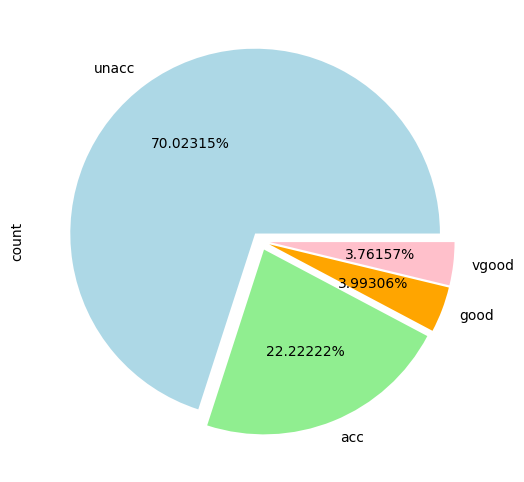

In [9]:
fig_size=plt.rcParams['figure.figsize']
fig_size[0]=8
fig_size[1]=6
plt.rcParams['figure.figsize']=fig_size
dataset.output.value_counts().plot(kind='pie',autopct='%0.05f%%',
                                  colors=['lightblue','lightgreen','orange','pink']
                                  ,explode=(0.05,0.05,0.05,0.05))


In [15]:
categorical_columns=['price','maint','doors','persons','lug_capacity','safety']
for category in categorical_columns:
  dataset[category]=dataset[category].astype('category') #데이터를 범주형으로 변환
price=dataset['price'].cat.codes.values
maint=dataset['maint'].cat.codes.values
doors=dataset['doors'].cat.codes.values
persons=dataset['persons'].cat.codes.values
lug_capacity=dataset['lug_capacity'].cat.codes.values
safety=dataset['safety'].cat.codes.values

categorical_data=np.stack([price,maint,doors,persons,lug_capacity,safety],1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

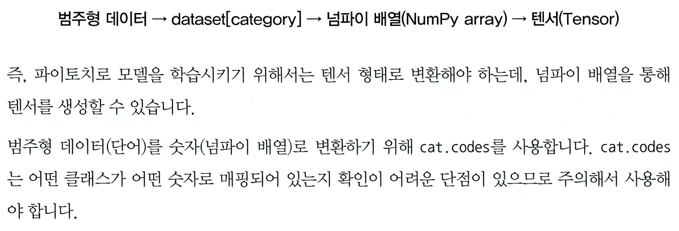

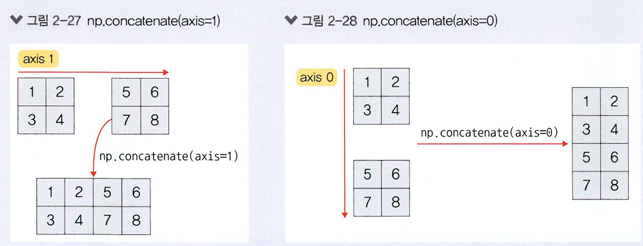

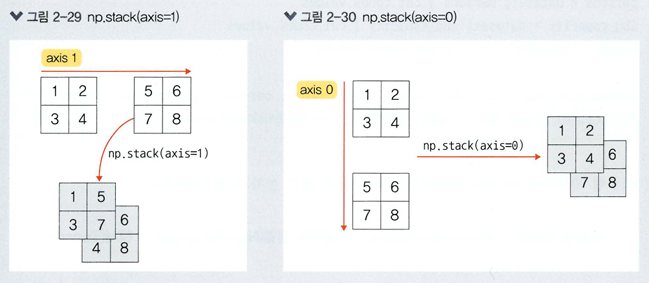

이제 torch 모률을 이용하여 배열을 텐서로 변환합니다.

In [16]:
categorical_data=torch.tensor(categorical_data,dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

마지막으로 레이블(outputs)로 사용할 칼럼에 대해서도 텐서로 변환

In [17]:
outputs=pd.get_dummies(dataset.output)
outputs=outputs.values
outputs=torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


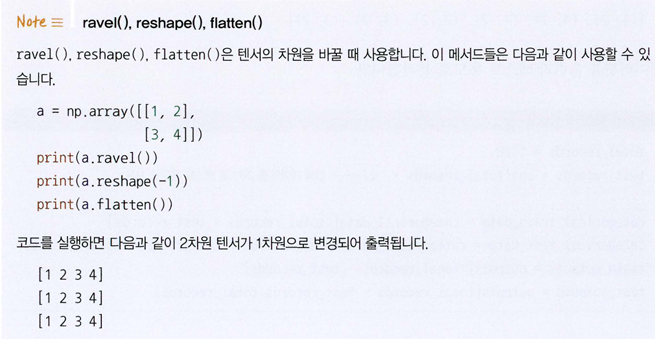

https://chatgpt.com/s/t_69d269317250819195aa577e2c572b9a


워드 임베딩은 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법입니다. 또한， 높은 차원의
임버l딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있습니다. 따라서 단일 숫자로 변환된 념
파이 배열을N차원으로 변경하여 사용합니다.
배열을 N차원으로 변환하기 위해 먼저 모든 범주형 칼럼에 대한 임베딩 크기(벡터 차원)를 정의
합니다. 임베딩 크기에 대한 정확한 규칙은 없지만 칼럼의 고유 값 수를 2로 나누는 것을 많이 사
용합니다. 에를 들어 price 칼럼은 네 개의 고유 값을 갖기 때문에 임베딩 크기는 4/2=2입니다.

In [20]:
categorical_column_sizes=[len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes=[(col_size, min(50,(col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


 (모든 범주형 칼럼의 고유 값 수 차원의 크기) 배열

In [36]:
total_records=1728
test_records=int(total_records*.2)
categorical_train_data=categorical_data[:total_records-test_records]
categorical_test_data=categorical_data[total_records-test_records:total_records]
train_outputs=outputs[:total_records-test_records]
test_outputs=outputs[total_records-test_records:total_records]

In [37]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


 모델의 네트워크를 생성

In [39]:
class Model(nn.Module):
  def __init__(self,embedding_size,output_size,layers,p=0.4):
    super().__init__()
    self.all_embeddings=nn.ModuleList([nn.Embedding(ni,nf) for ni, nf in embedding_size])

    self.embedding_dropout=nn.Dropout(p)
    all_layers=[]
    num_categorical_cols=sum((nf for ni,nf in embedding_size))
    input_size=num_categorical_cols

    for i in layers:
      all_layers.append(nn.Linear(input_size,i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size=i
    all_layers.append(nn.Linear(layers[-1],output_size))
    self.layers=nn.Sequential(*all_layers)
  def forward(self,x_categorical): # 학습 데이터를 입력받아서 연산/ 모델 객체를 데이터와 함께 호출하면 자동으로 실행
    embeddings=[]
    for i,e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))
    x=torch.cat(embeddings,1)
    x=self.embedding_dropout(x)
    x=self.layers(x)
    return x


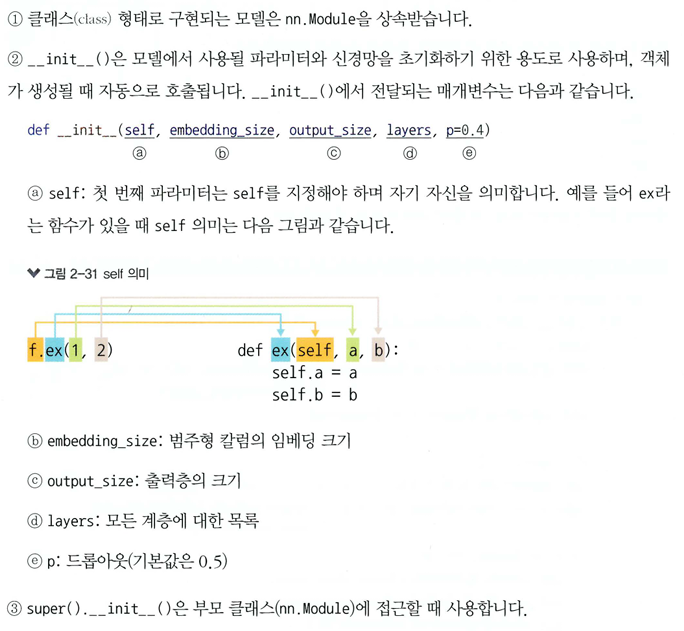

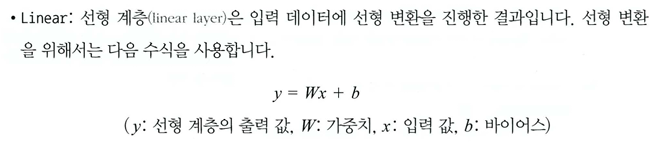

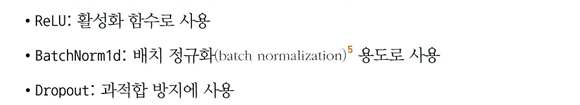

In [40]:
model=Model(categorical_embedding_sizes,4,[200,100,50],p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [31]:
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

 GPU가 있다면 GPU를 시용하고， 없다면 CPU를 사용
하도록하는코드

In [32]:
if torch.cuda.is_available():
  device=torch.device('cuda')
else:
  device=torch.device('cpu')

In [41]:
epochs=500
aggregated_losses=[]
train_outputs=train_outputs.to(device=device,dtype=torch.int64)
for i in range(epochs):
  i+=1
  y_pred=model(categorical_train_data).to(device)
  single_loss=loss_function(y_pred,train_outputs)
  aggregated_losses.append(single_loss)

  if i%25==1:
    print(f'epoch:{i:3} loss:{single_loss.item():10.8f}')
  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()
print(f'epoch:{i:3} loss: {single_loss.item():10.10f}')

epoch:  1 loss:1.66795516
epoch: 26 loss:1.67714489
epoch: 51 loss:1.65426064
epoch: 76 loss:1.64567375
epoch:101 loss:1.66405725
epoch:126 loss:1.64637971
epoch:151 loss:1.62888789
epoch:176 loss:1.63504660
epoch:201 loss:1.64191175
epoch:226 loss:1.68166959
epoch:251 loss:1.66235244
epoch:276 loss:1.67685592
epoch:301 loss:1.66773427
epoch:326 loss:1.65469527
epoch:351 loss:1.68316579
epoch:376 loss:1.65082943
epoch:401 loss:1.66425347
epoch:426 loss:1.67128253
epoch:451 loss:1.65821350
epoch:476 loss:1.66438401
epoch:500 loss: 1.6523269415


In [42]:
test_outputs=test_outputs.to(device=device,dtype=torch.int64)
with torch.no_grad():
  y_val=model(categorical_test_data)
  loss=loss_function(y_val,test_outputs)
print(f'Loss: {loss:8f}')

Loss: 1.605665


In [43]:
print(y_val[:5])

tensor([[-0.7687,  0.9919,  0.9089,  0.6951],
        [-0.2863,  0.5677,  0.6561, -0.0905],
        [-1.8525, -0.1999, -0.6617, -0.9889],
        [ 0.2313, -0.5957, -0.1543, -0.0899],
        [ 0.6547, -0.4143, -0.0718,  0.8574]])


In [44]:
y_val=np.argmax(y_val,axis=1)
print(y_val[:5])

tensor([1, 2, 1, 0, 3])


In [45]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs,y_val))
print(accuracy_score(test_outputs,y_val))

[[42 68 95 54]
 [10 20 35 21]
 [ 0  0  0  0]
 [ 0  0  0  0]]
              precision    recall  f1-score   support

           0       0.81      0.16      0.27       259
           1       0.23      0.23      0.23        86
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0

    accuracy                           0.18       345
   macro avg       0.26      0.10      0.12       345
weighted avg       0.66      0.18      0.26       345

0.17971014492753623


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
